<a href="https://colab.research.google.com/github/sabbirpuspo/LearningforMe/blob/main/Skill_Morph_9_DS3_Ensemble.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensemble Models: Bagging, Boosting & Stacking

**Course Instructor:** Md. Samiul Islam

**Dataset:** Kaggle business datasets (AI Job Market 2026 + Superstore Sales)

---

## Table of Contents

1. Setup & Installation
2. Introduction to Ensemble Learning
3. Dataset: AI Job Market 2026
4. Data Exploration
5. Data Cleaning
6. Preprocessing & Train/Test Split
7. Model 1: Random Forest
8. Model 2: Extra Trees
9. Model 3: XGBoost
10. Model 4: LightGBM
11. Model 5: CatBoost
12. Model 6: Stacking Ensemble
13. Model Comparison
14. Classification Report
15. Confusion Matrix
16. ROC Curve & AUC Score
17. Cross-Validation
18. Key Takeaways
19. Homework Assignment

---

## 1. Setup & Installation

In [1]:
# Install boosting libraries
!pip install xgboost lightgbm catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.0 MB/s eta 0:00:00


In [2]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing and model selection
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

# Ensemble models
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, StackingClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score,
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 20   # same seed everywhere -> reproducible results

## 2. Introduction to Ensemble Learning

An **ensemble** combines many models to get a better prediction than any single model.

| Type | Idea | Models |
|---|---|---|
| **Bagging** | Many models trained **in parallel** on random samples, then averaged | Random Forest, Extra Trees |
| **Boosting** | Models trained **one after another**, each fixing earlier errors | XGBoost, LightGBM, CatBoost |
| **Stacking** | A **meta-model** learns how to combine different models | Stacking Classifier |

## 3. Dataset: AI Job Market 2026

**Source:** Kaggle

**Link:** https://www.kaggle.com/datasets/mariaaqdas/ai-job-market-2026-automation-vs-traditional-role

**Description:** Job postings from the US, UK and India (2026)

**Features used:**
- Job category
- Contract type (permanent / contract)
- Contract time (full time / part time)
- Country
- Average salary
- Salary is predicted (0/1)

**Target:** `is_ai_related` → 0 = Traditional role, 1 = AI-related role

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets/ai_job_market_dataset.csv')
df.head()

Mounted at /content/drive


,search_keyword,search_country,id,title,company,location,category,contract_type,contract_time,salary_min,salary_max,salary_is_predicted,created,description,is_ai_related,salary_avg,created_date,currency,country_name
0,artificial intelligence,gb,5822242641,Senior Technologist Artificial Intelligence R ...,Hackajob Ltd,"Great Baddow, Chelmsford",Engineering Jobs,permanent,NaN,40000.00,40000.00,0,2026-07-31 11:09:48+00:00,hackajob is partnering directly with BAE Syste...,True,40000.00,2026-07-31,GBP,United Kingdom
1,artificial intelligence,gb,5727313687,Artificial Intelligence,Adria Solutions,"Altrincham, Greater Manchester",IT Jobs,NaN,NaN,53702.83,53702.83,1,2026-05-12 22:05:22+00:00,AI Engineer - Manchester - Circa £50K Our clie...,True,53702.83,2026-05-12,GBP,United Kingdom
2,artificial intelligence,gb,5736675451,Artificial Intelligence Engineer,Oxford Dynamics,UK,IT Jobs,permanent,full_time,74422.25,74422.25,1,2026-05-21 21:07:04+00:00,Artificial Intelligence Engineers Contract: Pe...,True,74422.25,2026-05-21,GBP,United Kingdom
3,artificial intelligence,gb,5824444000,Artificial Intelligence Engineer,Quantiphi,"London, UK",IT Jobs,NaN,full_time,53031.54,53031.54,1,2026-08-01 18:29:25+00:00,"While technology is the heart of our business,...",True,53031.54,2026-08-01,GBP,United Kingdom
4,artificial intelligence,gb,5844156514,Artificial Intelligence Engineer,Discover International,"Monument, Central London",IT Jobs,contract,full_time,52000.00,60000.00,0,2026-08-16 11:39:19+00:00,"Salary: £52,000 - 60,000 per year Requirements...",True,56000.00,2026-08-16,GBP,United Kingdom


## 4. Data Exploration

In [ ]:
# Column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   search_keyword       1696 non-null   object 
 1   search_country       1696 non-null   object 
 2   id                   1696 non-null   int64  
 3   title                1696 non-null   object 
 4   company              1695 non-null   object 
 5   location             1696 non-null   object 
 6   category             1696 non-null   object 
 7   contract_type        432 non-null    object 
 8   contract_time        826 non-null    object 
 9   salary_min           1513 non-null   float64
 10  salary_max           1513 non-null   float64
 11  salary_is_predicted  1696 non-null   int64  
 12  created              1696 non-null   object 
 13  description          1696 non-null   object 
 14  is_ai_related        1696 non-null   bool   
 15  salary_avg           1513 non-null   f

In [ ]:
# Summary statistics of numeric columns
df.describe().round(2)

,id,salary_min,salary_max,salary_is_predicted,salary_avg
count,1.696000e+03,1513.00,1513.00,1696.00,1513.00
mean,5.771004e+09,77299.04,87277.96,0.68,82288.50
std,3.734309e+08,97136.33,183696.58,0.46,137576.35
min,1.155089e+09,0.00,13.00,0.00,13.00
25%,5.805809e+09,34886.79,35043.05,0.00,35000.00
50%,5.830417e+09,54600.00,55145.76,1.00,55000.00
75%,5.841228e+09,97600.78,100000.00,1.00,98968.77
max,5.846513e+09,2000000.00,5000000.00,1.00,3500000.00


## 5. Data Cleaning

- Keep only the columns we use as features
- Fill missing values
- Convert the target to 0/1

In [ ]:
TARGET = "is_ai_related"
class_names = ["Traditional", "AI-related"]

features = ["category", "contract_type", "contract_time", "country_name",
            "salary_avg", "salary_is_predicted"]
df = df[features + [TARGET]].copy()

# Fill missing values
df["contract_type"] = df["contract_type"].fillna("unknown")
df["contract_time"] = df["contract_time"].fillna("unknown")
df["salary_avg"]    = df["salary_avg"].fillna(df["salary_avg"].median())

df[TARGET] = df[TARGET].astype(int)
df = df.drop_duplicates()
df.head()

,category,contract_type,contract_time,country_name,salary_avg,salary_is_predicted,is_ai_related
0,Engineering Jobs,permanent,unknown,United Kingdom,40000.00,0,1
1,IT Jobs,unknown,unknown,United Kingdom,53702.83,1,1
2,IT Jobs,permanent,full_time,United Kingdom,74422.25,1,1
3,IT Jobs,unknown,full_time,United Kingdom,53031.54,1,1
4,IT Jobs,contract,full_time,United Kingdom,56000.00,0,1


## 6. Preprocessing & Train/Test Split

In [ ]:
# Features (X) and target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Convert text columns to numbers
for col in X.select_dtypes(exclude="number").columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))

X.head()

,category,contract_type,contract_time,country_name,salary_avg,salary_is_predicted
0,5,1,2,1,40000.00,0
1,10,2,2,1,53702.83,1
2,10,1,0,1,74422.25,1
3,10,2,0,1,53031.54,1
4,10,0,0,1,56000.00,0


In [ ]:
# Stratified 80/20 split keeps class proportions equal in train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples : {len(X_test)}")

Training samples: 1158
Testing samples : 290


## 7. Model 1: Random Forest

- Many decision trees trained on random samples of the data (**bagging**)
- Final prediction = majority vote of all trees

In [ ]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_pred  = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)   # probabilities -> needed for ROC/AUC

print(f"Random Forest | accuracy = {accuracy_score(y_test, rf_pred):.4f}")

Random Forest | accuracy = 0.9241


## 8. Model 2: Extra Trees

- Like Random Forest, but split points are chosen **randomly**
- Faster, and often less overfitting

In [ ]:
# Extra Trees
et_model = ExtraTreesClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
et_model.fit(X_train, y_train)

et_pred  = et_model.predict(X_test)
et_proba = et_model.predict_proba(X_test)

print(f"Extra Trees | accuracy = {accuracy_score(y_test, et_pred):.4f}")

Extra Trees | accuracy = 0.9207


## 9. Model 3: XGBoost

- Trees are built **one after another**; each new tree fixes the errors of the previous ones (**boosting**)
- Great balance of speed and accuracy

In [ ]:
# XGBoost
xgb_model = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                              random_state=RANDOM_STATE)
xgb_model.fit(X_train, y_train)

xgb_pred  = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)

print(f"XGBoost | accuracy = {accuracy_score(y_test, xgb_pred):.4f}")

XGBoost | accuracy = 0.9448


## 10. Model 4: LightGBM

- Boosting with fast, histogram-based trees
- Best for large datasets

In [ ]:
# LightGBM
lgb_model = lgb.LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                               random_state=RANDOM_STATE, verbose=-1)
lgb_model.fit(X_train, y_train)

lgb_pred  = lgb_model.predict(X_test)
lgb_proba = lgb_model.predict_proba(X_test)

print(f"LightGBM | accuracy = {accuracy_score(y_test, lgb_pred):.4f}")

LightGBM | accuracy = 0.9414


## 11. Model 5: CatBoost

- Boosting designed for categorical features
- Robust with little tuning

In [ ]:
# CatBoost
cat_model = CatBoostClassifier(iterations=200, learning_rate=0.1, depth=5,
                               random_state=RANDOM_STATE, verbose=0)
cat_model.fit(X_train, y_train)

cat_pred  = cat_model.predict(X_test).ravel().astype(int)   # flatten to 1-D labels
cat_proba = cat_model.predict_proba(X_test)

print(f"CatBoost | accuracy = {accuracy_score(y_test, cat_pred):.4f}")

CatBoost | accuracy = 0.9483


## 12. Model 6: Stacking Ensemble

- The 5 models above are the **base models**
- A **meta-model** (Logistic Regression) learns how to combine their predictions

In [ ]:
# Stacking: 5 base models + Logistic Regression as the meta-model
stack_model = StackingClassifier(
    estimators=[("rf", rf_model), ("et", et_model), ("xgb", xgb_model),
                ("lgb", lgb_model), ("cat", cat_model)],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
)
stack_model.fit(X_train, y_train)

stack_pred  = stack_model.predict(X_test)
stack_proba = stack_model.predict_proba(X_test)

print(f"Stacking | accuracy = {accuracy_score(y_test, stack_pred):.4f}")

Stacking | accuracy = 0.9517


## 13. Model Comparison

All models compared on the test set: accuracy, precision, recall, F1 score (macro and weighted average) and ROC-AUC.

In [ ]:
models = {
    "Random Forest": (rf_pred, rf_proba),
    "Extra Trees":   (et_pred, et_proba),
    "XGBoost":       (xgb_pred, xgb_proba),
    "LightGBM":      (lgb_pred, lgb_proba),
    "CatBoost":      (cat_pred, cat_proba),
    "Stacking":      (stack_pred, stack_proba),
}

rows = []
for name, (pred, proba) in models.items():
    rows.append({
        "Model":                name,
        "Accuracy":             accuracy_score(y_test, pred),
        "Precision (macro)":    precision_score(y_test, pred, average="macro"),
        "Recall (macro)":       recall_score(y_test, pred, average="macro"),
        "F1 (macro)":           f1_score(y_test, pred, average="macro"),
        "Precision (weighted)": precision_score(y_test, pred, average="weighted"),
        "Recall (weighted)":    recall_score(y_test, pred, average="weighted"),
        "F1 (weighted)":        f1_score(y_test, pred, average="weighted"),
        "ROC-AUC":              roc_auc_score(y_test, proba[:, 1]),
    })

results = pd.DataFrame(rows).sort_values("F1 (macro)", ascending=False).reset_index(drop=True)
best_model = results.iloc[0]["Model"]
results.round(4)

,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro),Precision (weighted),Recall (weighted),F1 (weighted),ROC-AUC
0,Stacking,0.9517,0.9527,0.9486,0.9505,0.9519,0.9517,0.9516,0.9822
1,CatBoost,0.9483,0.9486,0.9456,0.9470,0.9483,0.9483,0.9482,0.9796
2,XGBoost,0.9448,0.9456,0.9416,0.9434,0.9449,0.9448,0.9447,0.9814
3,LightGBM,0.9414,0.9405,0.9396,0.9401,0.9413,0.9414,0.9413,0.9776
4,Random Forest,0.9241,0.9214,0.9246,0.9228,0.9248,0.9241,0.9243,0.9809
5,Extra Trees,0.9207,0.9181,0.9205,0.9192,0.9211,0.9207,0.9208,0.9588


### Macro vs. Weighted Average

| Average | How it is computed | Meaning |
|---|---|---|
| **Macro** | Simple mean of the per-class scores | Every class counts **equally** |
| **Weighted** | Mean weighted by the number of samples in each class | Bigger classes count **more** |



## 14. Confusion Matrix

Rows = **actual** class, columns = **predicted** class. The diagonal shows correct predictions.

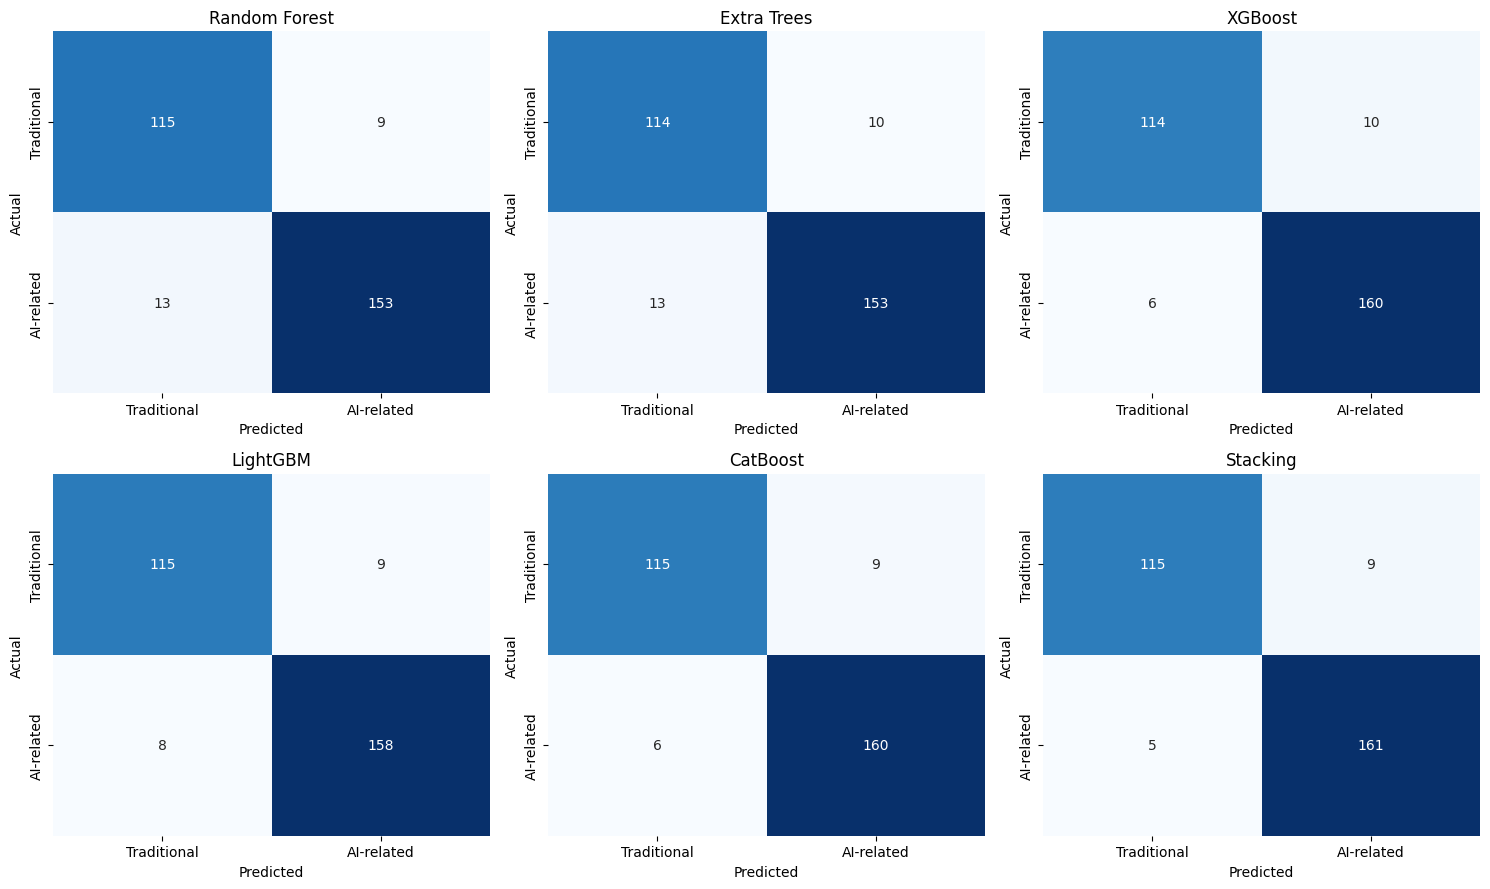

In [ ]:
# Confusion matrix for every model
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for ax, (name, (pred, proba)) in zip(axes.ravel(), models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 16. ROC Curve & AUC Score

The ROC curve shows how well each model separates the classes.
A higher AUC (closer to 1.0) means better performance.

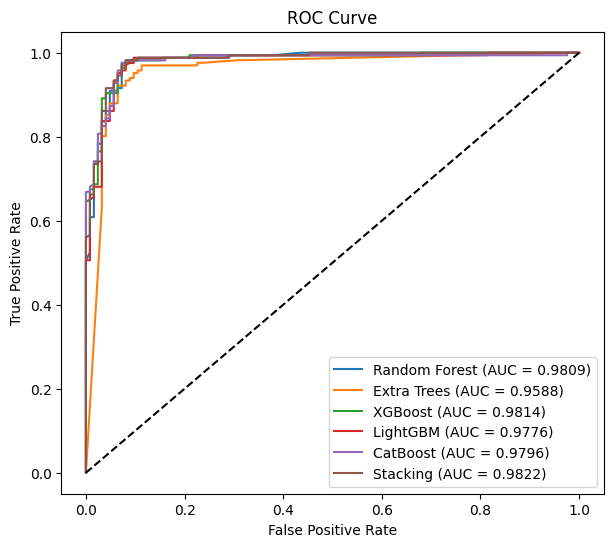

In [ ]:
# ROC curve + AUC for all six models
plt.figure(figsize=(7, 6))
for name, (pred, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test, proba[:, 1])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr, tpr):.4f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## 17. Key Takeaways

1. **Bagging** (Random Forest, Extra Trees): strong and simple baselines
2. **Boosting** (XGBoost, LightGBM, CatBoost): usually the best single models on tabular data
3. **Stacking**: combines different models; often a small extra gain, but slower

**Evaluation:**
- **Accuracy** alone is not enough – also check precision, recall and F1
- **Macro average** treats all classes equally; **weighted average** follows class size
- **Confusion matrix** shows *which* classes are confused
- **ROC-AUC** measures how well the model separates the classes (1.0 = perfect)

**Important parameters:**
- **n_estimators / iterations:** number of trees
- **learning_rate:** step size of boosting
- **max_depth / depth:** tree complexity

---

## 19. Homework Assignment

### 📝 Task: Superstore Profitability Prediction

**Dataset:** Superstore Sales

**Kaggle Link:** https://www.kaggle.com/datasets/himanshuuike/superstore-sales-dataset

**File:** `samplesuperstore.csv` (upload to `MyDrive/datasets/`)

**Target:** create `profit_class` from the profit margin (= Profit / Sales):

| Class | Rule |
|---|---|
| 0 – Loss | Profit < 0 |
| 1 – Low margin | margin < 0.25 |
| 2 – High margin | margin ≥ 0.25 |

---

### Tasks:

**Task 1: Load & Explore Data**
- Load the dataset from Google Drive
- Display first rows, `info()`, `describe()`

**Task 2: Clean Data**
- Create the `profit_class` target
- Keep features: Ship Mode, Segment, Region, Category, Sub-Category, Sales, Quantity, Discount
- Drop the `Profit` column

**Task 3: Preprocess**
- Encode text columns with `LabelEncoder`
- Stratified train/test split (80/20, `random_state=20`)

**Task 4: Train Models**
- Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, Stacking

**Task 5: Evaluate**
- Comparison table: accuracy, precision, recall, F1 (macro and weighted), ROC-AUC
- Classification report for every model

**Task 6: Visualize**
- Confusion matrix for every model
- ROC curve (one-vs-rest) + AUC for every model


---



### Homework Starter Code:

Use the cells below to complete your homework.

In [ ]:
# TASK 1: Load and Explore Data
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/datasets/samplesuperstore.csv')
df.head()

# TODO: info(), describe(), correlation heatmap

In [ ]:
# TASK 2: Clean Data

# TODO: Create profit_class (0 = Loss, 1 = Low margin, 2 = High margin)
TARGET = "profit_class"
class_names = ["Loss", "Low margin", "High margin"]

margin = df["Profit"] / df["Sales"]
df[TARGET] = np.select([df["Profit"] < 0, margin < 0.25], [0, 1], default=2)

features = ["Ship Mode", "Segment", "Region", "Category", "Sub-Category",
            "Sales", "Quantity", "Discount"]
df = df[features + [TARGET]].drop_duplicates()
df.head()
# TODO: Keep the selected features + target
# TODO: Drop Profit

In [ ]:
# TASK 3: Preprocess

# TODO: Encode text columns
# TODO: Split data

In [ ]:
# TASK 4: Train Models

# TODO: Random Forest
# TODO: Extra Trees
# TODO: XGBoost
# TODO: LightGBM
# TODO: CatBoost
# TODO: Stacking

In [ ]:
# TASK 5: Evaluate

# TODO: Comparison table
# TODO: Classification reports

In [ ]:
# TASK 6: Visualize

# TODO: Confusion matrices
# TODO: ROC curves + AUC